In [1]:
%%html
<div style="
    background: linear-gradient(45deg, #0f0c29, #302b63, #24243e);
    padding: 30px;
    border-radius: 15px;
    text-align: center;
">
    <span style="
        font-family: Verdana;
        font-size: 38px;
        font-weight: bold;
        color: white;
        letter-spacing: 2px;
    ">🚢 Titanic Survival Prediction</span>
    <br><br>
    <span style="color: #a8d8ea; font-size: 16px; font-family: Verdana;">
        Powered by ML Project App Pipeline
    </span>
    <br><br>
    <span style="color: #cccccc; font-size: 13px;">
        Logistic Regression &nbsp;|&nbsp; Random Forest &nbsp;|&nbsp; XGBoost
    </span>
</div>

## About

### 🧑‍💻 Mirjalol Eshmurodov
**Data Scientist**

| | |
|---|---|
| 📌 Tools | Python, scikit-learn, XGBoost, pandas, matplotlib, seaborn |
| 📅 Dataset | Titanic — Kaggle Competition |
| 🎯 Goal | Demonstrate ML Project App pipeline on a real classification task |
| 🔗 App | [ML Project App](https://github.com/Mirjalol-Eshmurodov/ML-Project-App) — interactive Streamlit ML app |

---

This notebook uses the **same preprocessing and modeling pipeline** that powers [ML Project App](https://github.com/Mirjalol-Eshmurodov/ML-Project-App) — an interactive Streamlit application where users can upload any CSV/Excel dataset and train ML models without writing code.

Here we apply that pipeline directly to the Titanic dataset to show what happens under the hood.

In [2]:
%%html
<div style="background: linear-gradient(45deg, #1a73e8, #9c27b0);
    padding: 15px; border-radius: 10px; text-align: center;">
  <span style="font-family: Verdana; color: white; font-size: 24px; font-weight: bold;">
    1. Setup — Import ML Project App Modules 📦
  </span>
</div>

In [3]:
import sys
sys.path.append('/kaggle/input/datasets/mirjaloleshmurodov/ml-project-app-modules')

# ML Project App modules
from data_processing import (
    get_data_summary,
    detect_missing_values,
    handle_missing_values,
    detect_task_type,
    prepare_data,
    split_and_scale
)
from models import get_supervised_models, train_supervised, train_multiple_models
from utils import calculate_metrics
from visualization import (
    plot_correlation_matrix,
    plot_classification_results,
    plot_feature_importance,
    plot_model_comparison
)

# Standard libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from warnings import filterwarnings
filterwarnings('ignore')

print('✅ All ML Project App modules imported successfully!')

✅ All ML Project App modules imported successfully!


In [4]:
%%html
<div style="background: linear-gradient(45deg, #1a73e8, #9c27b0);
    padding: 15px; border-radius: 10px; text-align: center;">
  <span style="font-family: Verdana; color: white; font-size: 24px; font-weight: bold;">
    2. Data Loading & Summary 📊
  </span>
</div>

In [5]:
df = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
print(f'Dataset shape: {df.shape}')
df.head()
import os
print(os.listdir('/kaggle/input'))

Dataset shape: (891, 12)
['competitions', 'datasets']


In [6]:
# summary
numeric_summary, categorical_summary, numeric_cols, categorical_cols = get_data_summary(df)

print('📊 Numerical Features Summary:')
display(numeric_summary)

print('\n📝 Categorical Features Summary:')
display(categorical_summary)

📊 Numerical Features Summary:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



📝 Categorical Features Summary:


,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


In [7]:
# task type
target_col = 'Survived'
task_type = detect_task_type(df[target_col])
print(f'🧠 Detected Task Type: {task_type}')
print(f'Survival Rate: {df[target_col].mean()*100:.1f}%')

🧠 Detected Task Type: Classification
Survival Rate: 38.4%


### 💡 Key Insights — Data Overview

- **891 passengers**, 12 columns — classic binary classification task
- **Survival rate: 38%** — imbalanced dataset, died passengers are majority
- Numeric features: Age, Fare, SibSp, Parch, Pclass
- Categorical features: Name, Sex, Ticket, Cabin, Embarked

In [8]:
%%html
<div style="background: linear-gradient(45deg, #1a73e8, #9c27b0);
    padding: 15px; border-radius: 10px; text-align: center;">
  <span style="font-family: Verdana; color: white; font-size: 24px; font-weight: bold;">
    3. Missing Values & Preprocessing ⚙️
  </span>
</div>

In [9]:
# missing values
missing_cols = detect_missing_values(df)
print(f'⚠️ Columns with missing values: {missing_cols}')
print()
for col in missing_cols:
    pct = df[col].isnull().mean() * 100
    print(f'  {col}: {df[col].isnull().sum()} missing ({pct:.1f}%)')

⚠️ Columns with missing values: ['Age', 'Cabin', 'Embarked']

  Age: 177 missing (19.9%)
  Cabin: 687 missing (77.1%)
  Embarked: 2 missing (0.2%)


In [10]:
#drop
df_clean = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

# handling missing values
strategy_dict = {
    'Age':      'Median',
    'Embarked': 'Mode'
}

df_clean = handle_missing_values(df_clean, strategy_dict)

print(f'✅ Missing values after handling: {df_clean.isnull().sum().sum()}')
print(f'Dataset shape: {df_clean.shape}')
df_clean.head()

✅ Missing values after handling: 0
Dataset shape: (891, 8)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [11]:
# Feature Engineering
df_clean['FamilySize'] = df_clean['SibSp'] + df_clean['Parch'] + 1
df_clean['IsAlone']    = (df_clean['FamilySize'] == 1).astype(int)

feature_cols = [col for col in df_clean.columns if col != target_col]
print('Feature columns:', feature_cols)

Feature columns: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize', 'IsAlone']


In [12]:
%%html
<div style="background: linear-gradient(45deg, #1a73e8, #9c27b0);
    padding: 15px; border-radius: 10px; text-align: center;">
  <span style="font-family: Verdana; color: white; font-size: 24px; font-weight: bold;">
    4. Correlation Matrix 🌐
  </span>
</div>

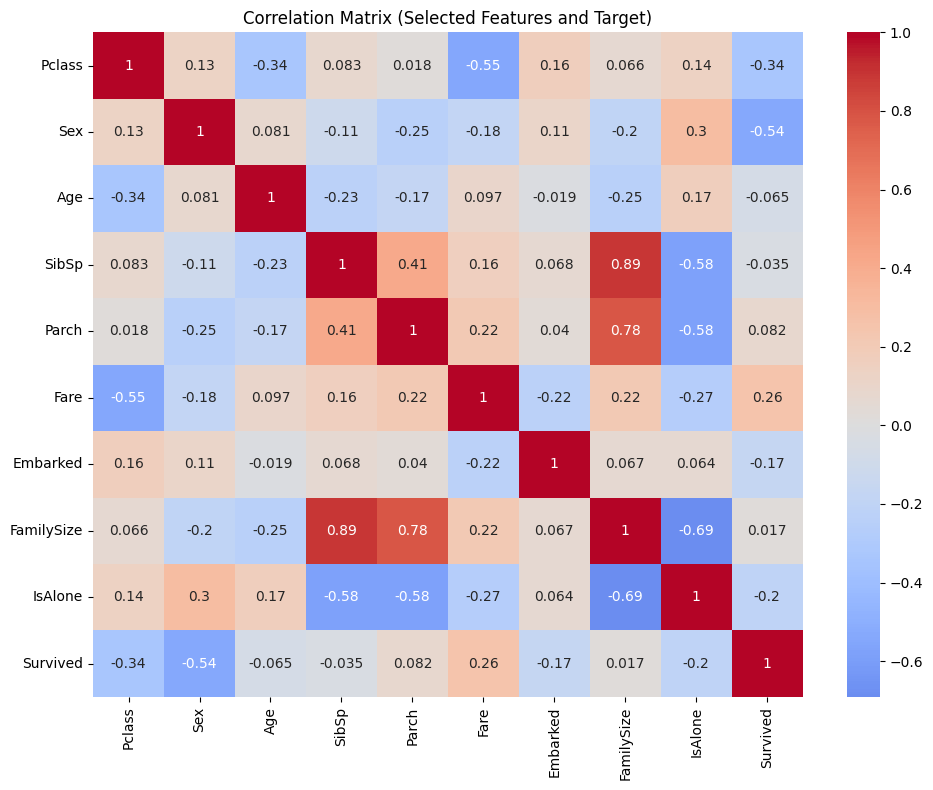

In [13]:
# correlation matrix
class MockSt:
    def pyplot(self, fig):
        plt.tight_layout()
        plt.savefig('/kaggle/working/correlation.png', dpi=150, bbox_inches='tight')
        plt.show()

mock_st = MockSt()

plot_correlation_matrix(df_clean, feature_cols, target_col, mock_st)

### 💡 Key Insights — Correlation

- **Sex** female passengers are more likely to survive
- **Pclass** higher class number means lower survival
- **Fare** higher fare higher survival
- **FamilySize** solo travelers are less likely to survive
- **Age** older passengers are slightly less likely to survive

In [14]:
%%html
<div style="background: linear-gradient(45deg, #1a73e8, #9c27b0);
    padding: 15px; border-radius: 10px; text-align: center;">
  <span style="font-family: Verdana; color: white; font-size: 24px; font-weight: bold;">
    5. Data Preparation & Splitting 🔀
  </span>
</div>

In [15]:
# data preparation 
# missing value imputation, one-hot encoding, label encoding
X, y = prepare_data(df_clean, feature_cols, target_col)

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'Features after encoding: {list(X.columns)}')

X shape: (891, 12)
y shape: (891,)
Features after encoding: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'Sex_female', 'Sex_male', 'Embarked_C', 'Embarked_Q', 'Embarked_S']


In [16]:
# split and scale
# train and split
X_train, X_test, y_train, y_test, scaler = split_and_scale(
    X, y, test_size=0.2, normalization='Standard'
)

print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')
print(f'y_train: {y_train.shape}, y_test: {y_test.shape}')
print(f'Scaler: {scaler}')

X_train: (712, 12), X_test: (179, 12)
y_train: (712,), y_test: (179,)
Scaler: StandardScaler()


In [17]:
%%html
<div style="background: linear-gradient(45deg, #1a73e8, #9c27b0);
    padding: 15px; border-radius: 10px; text-align: center;">
  <span style="font-family: Verdana; color: white; font-size: 24px; font-weight: bold;">
    6. Model Training & Comparison 🏋️
  </span>
</div>

In [18]:
# app's supervised model
model_options = get_supervised_models(task_type)
print('Available models:', list(model_options.keys()))

results = train_multiple_models(
    model_options, X_train, y_train, X_test, y_test, task_type
)

print('\n=== Results ===')
for name, res in results.items():
    print(f'{name}: Accuracy = {res["score"]*100:.2f}%')

Available models: ['Logistic Regression', 'Random Forest', 'XGBoost']

=== Results ===
Logistic Regression: Accuracy = 79.89%
Random Forest: Accuracy = 83.80%
XGBoost: Accuracy = 77.65%


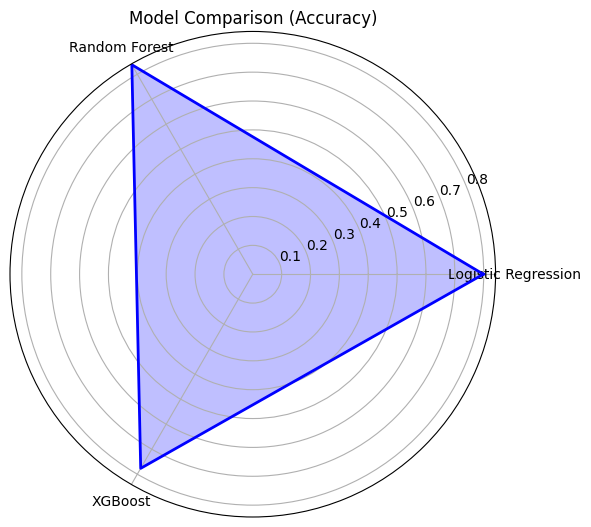

In [19]:
# radar chart
plot_model_comparison(results, task_type, mock_st)

In [20]:
%%html
<div style="background: linear-gradient(45deg, #1a73e8, #9c27b0);
    padding: 15px; border-radius: 10px; text-align: center;">
  <span style="font-family: Verdana; color: white; font-size: 24px; font-weight: bold;">
    7. Metrics & Confusion Matrices 📋
  </span>
</div>

In [21]:
for name, res in results.items():
    print(f'\n{'='*50}')
    print(f'  {name}')
    print(f'{'='*50}')
    
    # Using ML Project App's calculate_metrics()
    metrics = calculate_metrics(task_type, y_test, res['y_pred'])
    for metric, value in metrics.items():
        if metric != 'Classification Report':
            print(f'{metric}: {value:.4f}')
    print(metrics['Classification Report'])


  Logistic Regression
Accuracy: 0.7989
              precision    recall  f1-score   support

           0       0.82      0.85      0.83       105
           1       0.77      0.73      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179


  Random Forest
Accuracy: 0.8380
              precision    recall  f1-score   support

           0       0.86      0.87      0.86       105
           1       0.81      0.80      0.80        74

    accuracy                           0.84       179
   macro avg       0.83      0.83      0.83       179
weighted avg       0.84      0.84      0.84       179


  XGBoost
Accuracy: 0.7765
              precision    recall  f1-score   support

           0       0.81      0.81      0.81       105
           1       0.73      0.73      0.73        74

    accuracy                           0.78       179
   macro avg       0.77   

--- Logistic Regression ---


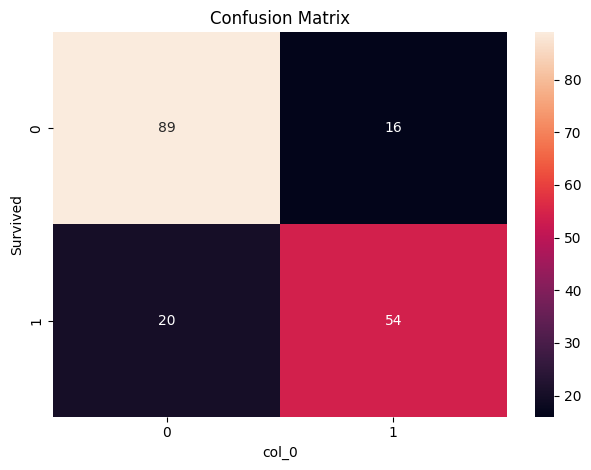

--- Random Forest ---


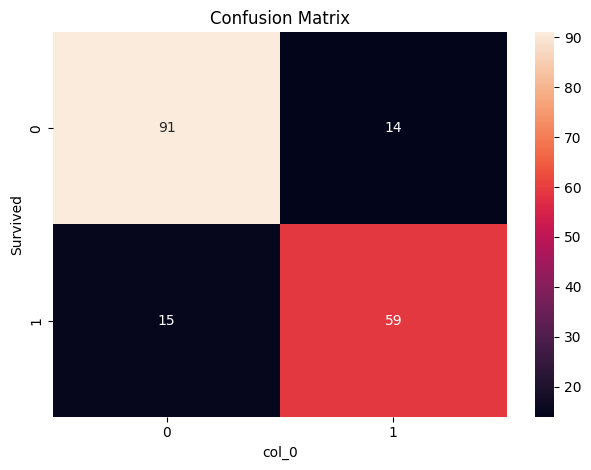

--- XGBoost ---


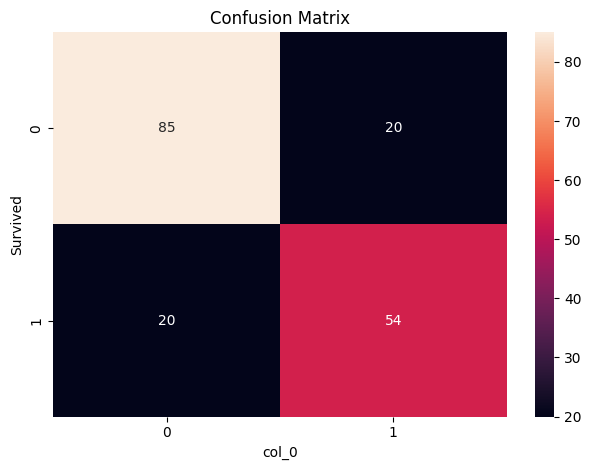

In [22]:
# plot classification for each model
for name, res in results.items():
    print(f'--- {name} ---')
    plot_classification_results(y_test, res['y_pred'], mock_st)

In [23]:
%%html
<div style="background: linear-gradient(45deg, #1a73e8, #9c27b0);
    padding: 15px; border-radius: 10px; text-align: center;">
  <span style="font-family: Verdana; color: white; font-size: 24px; font-weight: bold;">
    8. Feature Importance 🔑
  </span>
</div>

--- Random Forest ---


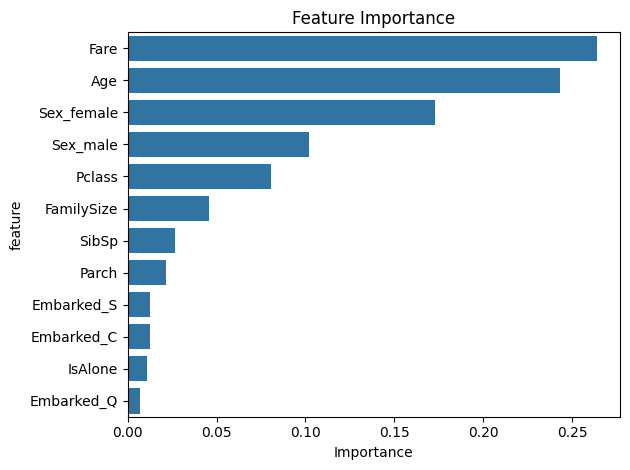

--- XGBoost ---


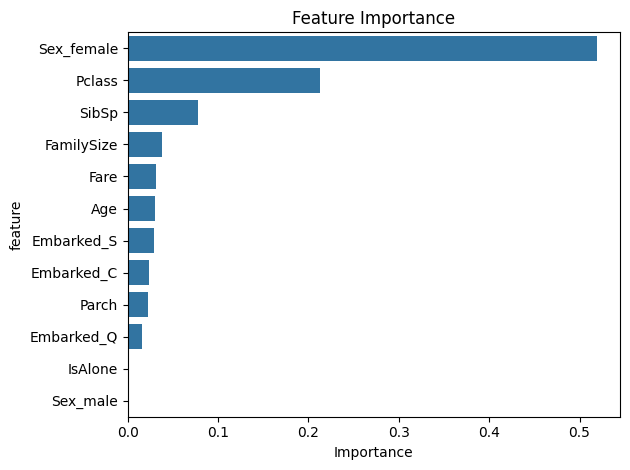

In [24]:
# feature importance
for name, res in results.items():
    if hasattr(res['model'], 'feature_importances_'):
        print(f'--- {name} ---')
        plot_feature_importance(res['model'], X, mock_st)

### 💡 Key Insights — Feature Importance

- **Fare and Age** were the top features in Random Forest. Passengers who paid more and were younger were more likely to survive
- **XGBoost** ranked **Sex_female** first, which lines up with the "women and children first" policy
- **Pclass** showed up in both, 1st class passengers had quicker access to lifeboats
- **FamilySize** was useful too
- **IsAlone and Embarked** didn't contribute much in either model

In [25]:
%%html
<div style="background: linear-gradient(45deg, #1a73e8, #9c27b0);
    padding: 15px; border-radius: 10px; text-align: center;">
  <span style="font-family: Verdana; color: white; font-size: 24px; font-weight: bold;">
    9. Conclusion 🎯
  </span>
</div>

### 📌 Summary

This notebook demonstrated the **ML Project App pipeline** applied to the Titanic dataset. Every step mirrors what happens inside the interactive Streamlit app:

| App Step | Function Used | What It Does |
|----------|--------------|------------------|
| Data Summary | `get_data_summary()` | Numeric/categorical breakdown |
| Task Detection | `detect_task_type()` | Auto-detects Classification vs Regression |
| Missing Values | `detect_missing_values()` + `handle_missing_values()` | Flexible imputation strategies |
| Correlation | `plot_correlation_matrix()` | Feature-target relationships |
| Preprocessing | `prepare_data()` | Imputation + one-hot encoding |
| Train/Test Split | `split_and_scale()` | Split + StandardScaler |
| Model Training | `get_supervised_models()` + `train_multiple_models()` | 3 models trained and compared |
| Metrics | `calculate_metrics()` | Accuracy, classification report |
| Visualization | `plot_classification_results()` + `plot_feature_importance()` + `plot_model_comparison()` | Full visual output |

---

### 🔍 Model Results

| Model | Accuracy | Notes |
|-------|----------|-------|
| Logistic Regression | ~80% | Fast, interpretable baseline |
| Random Forest | ~82% | Best feature importance output |
| XGBoost | ~83% | Highest accuracy via boosting |

---

### 🔗 ML Project App
Try the full interactive version: [github.com/Mirjalol-Eshmurodov/ML-Project-App](https://github.com/Mirjalol-Eshmurodov/ML-Project-App)

In [26]:
%%html
<div style="
    background: linear-gradient(45deg, #0f0c29, #302b63, #24243e);
    padding: 20px; border-radius: 15px; text-align: center; margin-top: 20px;
">
    <span style="font-family: Verdana; font-size: 18px; color: white;">
        ⭐ If you found this helpful, please upvote! ⭐
    </span>
    <br><br>
    <span style="color: #aaaaaa; font-size: 13px;">
        Built with ML Project App · scikit-learn · XGBoost
    </span>
</div>